In [11]:
# Run this cell whenever you restart your kernel!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

warnings.filterwarnings('ignore')
print("✅ Imports loaded into memory!")

✅ Imports loaded into memory!


In [3]:
# ==========================================
# 2. LOAD DATASET
# ==========================================

# Fetch California housing dataset from Scikit-Learn
raw_data = fetch_california_housing(as_frame=True)

# Combine features and target variable into a single DataFrame
df = raw_data.frame

# Display top 5 rows
print("Preview of the Dataset:")
df.head()

Preview of the Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Check dataset dimensions
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display statistical summary
print("Statistical Summary of Dataset:")
display(df.describe().T)

# Display dataset information (column types & non-null counts)
print("\nDataset Info:")
df.info()

Dataset Shape: 20640 rows, 9 columns

Statistical Summary of Dataset:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [2]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# 1. Fetch California housing dataset
raw_data = fetch_california_housing(as_frame=True)

# 2. Assign the DataFrame to 'df'
df = raw_data.frame

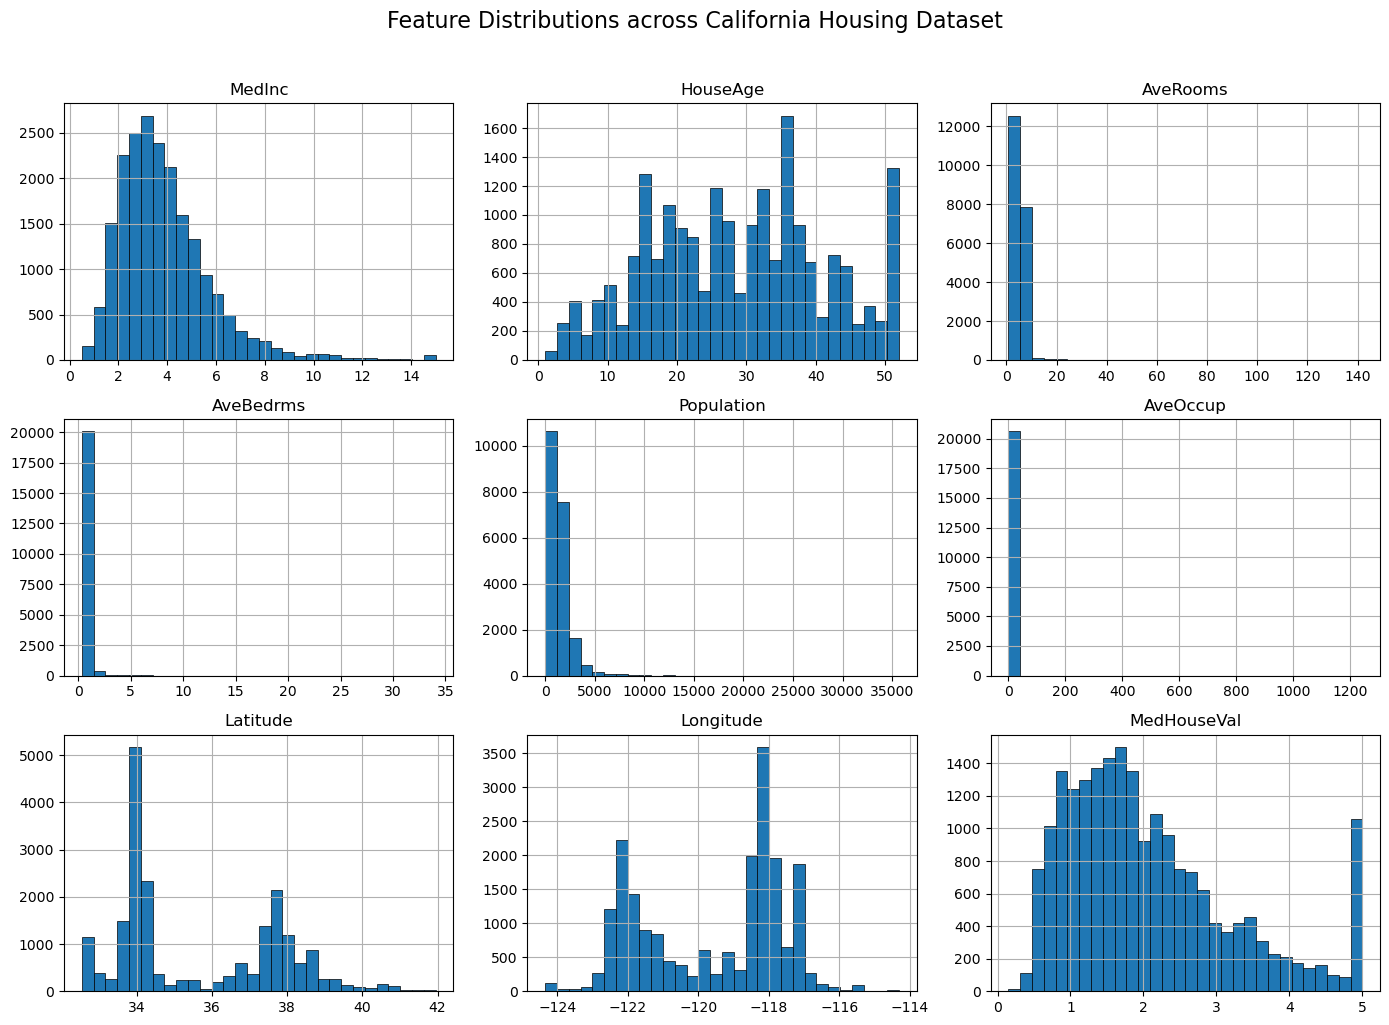

In [3]:
import matplotlib.pyplot as plt

# Plot histograms for all continuous variables
df.hist(figsize=(14, 10), bins=30, edgecolor="black", linewidth=0.5)
plt.suptitle("Feature Distributions across California Housing Dataset", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

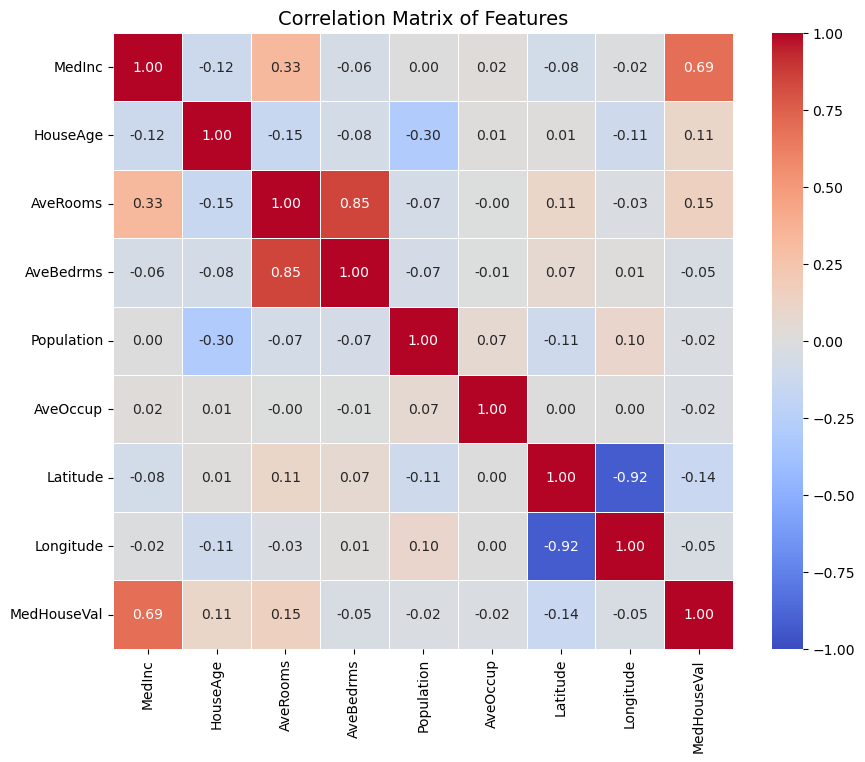

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute Pearson correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

# Draw heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Correlation Matrix of Features", fontsize=14)
plt.show()

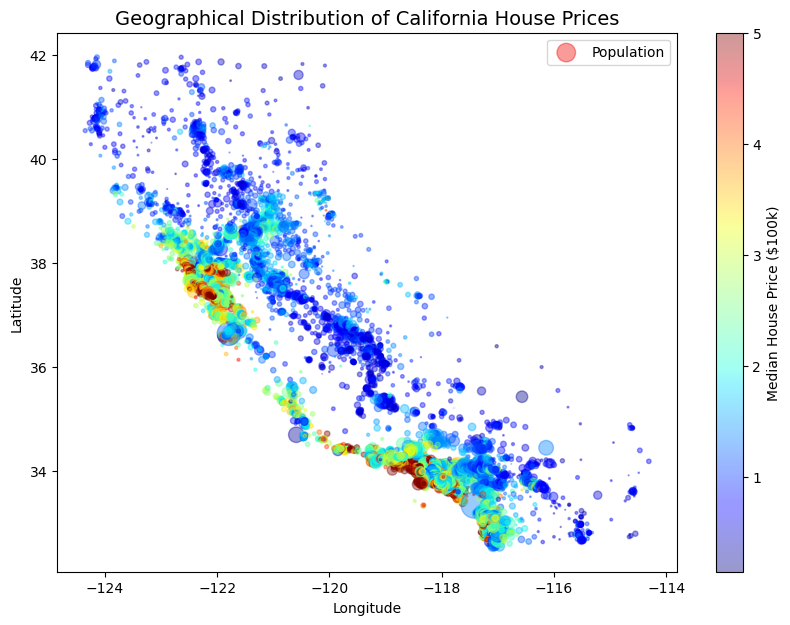

In [7]:
# Visualize California district pricing geographically
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    cmap="jet",
    s=df["Population"] / 100,
    alpha=0.4,
    label="Population"
)
plt.colorbar(scatter, label="Median House Price ($100k)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of California House Prices", fontsize=14)
plt.legend()
plt.show()

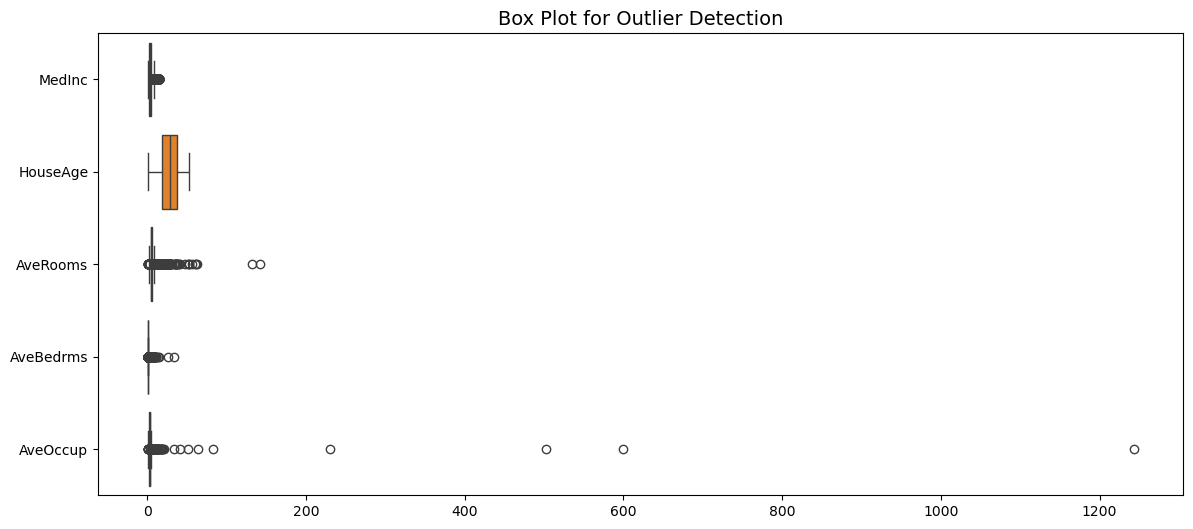

In [8]:
# Boxplot for key numerical features
features_to_check = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "AveOccup"]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[features_to_check], orient="h")
plt.title("Box Plot for Outlier Detection", fontsize=14)
plt.show()

In [9]:
# Step 1: Check missing values
missing_counts = df.isnull().sum()
print("Missing values per feature:\n", missing_counts)

# Step 2: Remove extreme geographical/occupancy outliers using IQR trimming
df_clean = df.copy()

features_for_iqr = ["AveRooms", "AveBedrms", "AveOccup", "Population"]

for col in features_for_iqr:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    # Filter DataFrame within bounds
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"\nRows before outlier removal: {len(df)}")
print(f"Rows after outlier removal:  {len(df_clean)}")

Missing values per feature:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Rows before outlier removal: 20640
Rows after outlier removal:  17293


In [12]:
# Import missing utilities from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create combined features
df_clean["RoomsPerHousehold"] = df_clean["AveRooms"] / df_clean["AveOccup"]
df_clean["BedroomsPerRoom"] = df_clean["AveBedrms"] / df_clean["AveRooms"]

# Separate Features (X) and Target (y)
X = df_clean.drop(columns=["MedHouseVal"])
y = df_clean["MedHouseVal"]

# Perform Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape:  {X_test_scaled.shape}")

X_train shape: (13834, 10)
X_test shape:  (3459, 10)


In [13]:
# Dictionary of regression models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Dictionary to store performance results
results = []

# Loop over models, train, evaluate
for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

# Convert results into a clean DataFrame
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
results_df.reset_index(drop=True, inplace=True)

display(results_df)

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest,0.324418,0.246462,0.496450,0.813383
1,Gradient Boosting,0.356697,0.272666,0.522175,0.793542
2,Linear Regression,0.467517,0.417995,0.646525,0.683501
3,Decision Tree,0.459313,0.506962,0.712012,0.616138


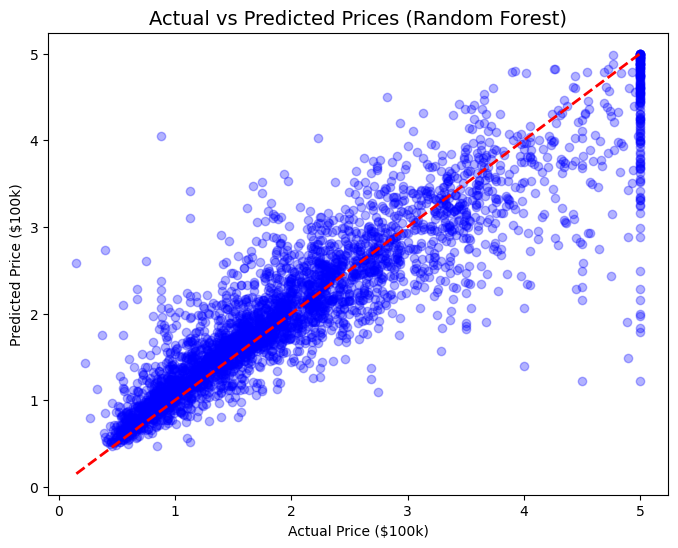

In [14]:
# Get best model name
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

# Generate predictions with best model
y_best_pred = best_model.predict(X_test_scaled)

# Plot actual vs predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_best_pred, alpha=0.3, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price ($100k)")
plt.ylabel("Predicted Price ($100k)")
plt.title(f"Actual vs Predicted Prices ({best_model_name})", fontsize=14)
plt.show()

In [15]:
# Save the trained model and feature scaler
joblib.dump(best_model, "california_housing_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f" Best model ({best_model_name}) and scaler saved successfully!")


def predict_house_price(input_features, feature_names):
    """
    Accepts raw feature inputs as a dictionary, scales them, and yields a prediction.
    """
    # Load model and scaler
    loaded_model = joblib.load("california_housing_model.pkl")
    loaded_scaler = joblib.load("scaler.pkl")

    # Format input data
    input_df = pd.DataFrame([input_features], columns=feature_names)

    # Scale inputs
    input_scaled = loaded_scaler.transform(input_df)

    # Predict value
    predicted_val = loaded_model.predict(input_scaled)[0]

    # Convert to actual dollar value ($100k multiplier)
    dollar_value = predicted_val * 100000
    return dollar_value


# Test sample prediction
sample_input = {
    "MedInc": 8.3252,
    "HouseAge": 41.0,
    "AveRooms": 6.9841,
    "AveBedrms": 1.0238,
    "Population": 322.0,
    "AveOccup": 2.5555,
    "Latitude": 37.88,
    "Longitude": -122.23,
    "RoomsPerHousehold": 6.9841 / 2.5555,
    "BedroomsPerRoom": 1.0238 / 6.9841
}

estimated_price = predict_house_price(sample_input, X.columns)
print(f"Sample Estimated House Price: ${estimated_price:,.2f}")

 Best model (Random Forest) and scaler saved successfully!
Sample Estimated House Price: $431,003.23
